# Project: The Invisible Risk — Deep Clustering & Anomaly Detection
## Phase II: Unsupervised Behavior Analysis of the LendingClub Portfolio (2.2M Records)

---

### 📑 Quick Navigation
* [1. Executive Summary](#1.-Executive-Summary)
* [2. Strategic Objectives](#2.-Strategic-Objectives)
* [3. Technical Pipeline](#3.-Methodology-&-Technical-Pipeline)
* [4. Operationalization Roadmap](#4.-Future-Roadmap:-(Operationalization))
* [5. Technical Stack](#5.-Technical-Stack)
* [6. Feature Selection Strategy](#6.-Feature-Selection-Strategy:-The-Behavioral-DNA)
* [7. Feature Glossary](#7.-Feature-Glossary:-Decoding-Behavioral-Inputs)

---

### 1. Executive Summary
Phase I successfully predicted loan defaults using supervised labels. **Phase II** transcends binary classification by treating credit risk as a hidden structural problem. By stripping away historical labels, this project utilizes **Unsupervised Machine Learning** to map the "latent space" of borrower behavior. 

**The Goal:** To identify hidden risk segments and **Black Swan anomalies**—highly unusual profiles that standard scoring models often overlook.

---

### 2. Strategic Objectives
* **🎯 Behavioral Segmentation:** Group **2.2 million** borrowers into "Financial Archetypes" to uncover the diverse profiles within the P2P ecosystem.
* **🔍 Black Swan Identification:** Deploy Anomaly Detection to isolate "out-of-distribution" borrowers exhibiting suspicious or extreme financial patterns.
* **📈 Risk Triangulation:** Cross-reference unsupervised clusters with actual outcomes to evaluate the model as an **Early Warning System (EWS)**.

---

### 3. Methodology and Technical Pipeline

#### I. Advanced Feature Engineering
Beyond raw data, we curated features reflecting **Financial Stress** and **Credit Velocity**:
* **Inquiry Intensity:** Normalizes credit-seeking behavior against the existing credit footprint.
* **Debt Burden (Loan-to-Income):** Measures the "weight" of debt relative to annual earnings.

#### II. The Transformation & Reduction Pipeline
To handle 2.2M records with high variance, I implemented a unified **Scikit-Learn Pipeline**:

> **💡 Methodological Note on Outliers:** > I applied **Winsorization (Capping at 99.5%)** specifically to stabilize the **K-Means centroids**. However, for the **Anomaly Detection** phase, we evaluate borrowers based on their deviation from these stabilized norms. This ensures "Black Swan" events are identified by multi-dimensional irregularity, rather than simply being ignored.

* **Log Transformation:** Applied `np.log1p` to features with **Skewness > 0.75** to normalize the "long tail" of financial data.
* **Robust Scaling:** Utilized Median/IQR centering to remain resilient against noise.
* **PCA:** Compressed high-dimensional data to 7 components, retaining **90% variance**.

#### III. AI Core Engine
* **MiniBatchKMeans:** Optimized batch-processing for high-volume clustering without memory exhaustion.
* **Isolation Forest:** Multi-dimensional outlier detection to identify "out-of-distribution" borrowers.

---

### 4. 🚀 Future Roadmap: Operationalization
Following the analysis, this project will advance to **Model Deployment**:
1. **Real-Time Predictor:** Creation of a `RiskScanner` function to categorize new applicants instantly.
2. **Feature Interpretability:** Implementing **SHAP** analysis to explain "Why" a borrower is flagged as high-risk.
3. **Interactive Dashboarding:** A **Streamlit** interface for stakeholders to visualize the 3D Risk Map.

---

### 5. Technical Stack
* **Engine:** Python (Jupyter), SQLite3
* **Modeling:** Scikit-learn (`PCA`, `MiniBatchKMeans`, `IsolationForest`)
* **Visualization:** Plotly (Interactive 3D Maps), Seaborn, Matplotlib

---

### 6. Feature Selection Strategy: The Behavioral DNA
We selected **13 key features** categorized into four critical dimensions. This ensures the model captures both the borrower's fundamental capacity to pay and their real-time financial trajectory.

| Dimension | Features | Strategic Rationale |
| :--- | :--- | :--- |
| **Solvency** | `annual_inc`, `dti`, `loan_to_inc`* | Assesses the fundamental ability to service debt and cover monthly cash-flow obligations. |
| **Commitment** | `loan_amnt`, `installment`, `int_rate` | Reflects the total capital at risk and the immediate "repayment pressure" on the borrower. |
| **Utilization** | `revol_bal`, `revol_util` | Indicates the borrower's reliance on revolving "safety nets" vs. their liquidity. |
| **Credit Velocity** | `inq_last_6mths`, `open_acc`, `pub_rec`, `inq_per_open_acc`* | Signals "credit hunger," portfolio complexity, or a history of derogatory public records. |

---

### 7. Feature Glossary: Decoding Behavioral Inputs

| Feature | Definition | Risk Context & Significance |
| :--- | :--- | :--- |
| **`annual_inc`** | Self-reported annual income. | The primary engine of repayment; higher values correlate with lower default risk. |
| **`dti`** | Debt-to-Income ratio. | Measures the percentage of monthly income committed to debt; a key indicator of leverage. |
| **`revol_util`** | Revolving line utilization rate. | A critical stress signal; utilization above 70% often indicates the borrower is "stretched." |
| **`inq_last_6mths`** | Hard credit inquiries (6 months). | A proxy for urgent cash needs; high velocity often signals an impending financial downturn. |
| **`pub_rec`** | Derogatory public records. | Bankruptcies or tax liens; a direct indicator of historical financial failure. |
| **`loan_to_inc`*** | Loan Amount / Annual Income. | **Engineered:** Measures the "weight" of the loan against yearly earnings to identify over-leverage. |

*\*Indicates a Custom Engineered Feature.*

# **3. Methodology & Technical Pipeline**
### I. Behavioral Feature Engineering


In [1]:
import sqlite3
import pandas as pd
import numpy as np

def retrieve_selected_features(db_path):
    # 1. Connect to the SQLite database
    conn = sqlite3.connect(db_path)

    # 2. Select behavioral features + the target (for later validation only)
    # We pull 'loan_status' but we will NOT use it for training the model.
    query = """
    SELECT annual_inc, dti, installment, loan_amnt,
    revol_bal, revol_util, inq_last_6mths,
    open_acc, pub_rec, int_rate, total_acc, loan_status FROM raw_loads"""

    df = pd.read_sql_query(query, conn)
    conn.close()

    print(f'Initial Shape: {df.shape}')

    # Basic Cleaning 
    # Dropping rows with missing values to ensure distance-based models function correctly
    df = df.dropna()

    # 4. Feature Engineering: Credit Velocity & Stress
    # Creating a 'Credit Hunger' index (inquiries relative to open accounts
    df['inq_per_open_acc'] = df['loan_amnt']/ (df['open_acc'] + 1)

    # Creating 'Loan-to-income' ration
    df['loan_to_inc'] = df['loan_amnt']/(df['annual_inc'] + 1)

    print(f'Shape after engineering & cleaning : {df.shape}')
    return df

# Udpate this path to the actual location on your Mac
DB_PATH = 'lending_club.db'
raw_df = retrieve_selected_features(DB_PATH)

# Preview the data
raw_df.head()  

Initial Shape: (2260701, 12)
Shape after engineering & cleaning : (2257158, 14)


,annual_inc,dti,installment,loan_amnt,revol_bal,revol_util,inq_last_6mths,open_acc,pub_rec,int_rate,total_acc,loan_status,inq_per_open_acc,loan_to_inc
0,55000.0,5.91,123.03,3600.0,2765.0,29.7,1.0,7.0,0.0,13.99,13.0,Fully Paid,450.000000,0.065453
1,65000.0,16.06,820.28,24700.0,21470.0,19.2,4.0,22.0,0.0,11.99,38.0,Fully Paid,1073.913043,0.379994
2,63000.0,10.78,432.66,20000.0,7869.0,56.2,0.0,6.0,0.0,10.78,18.0,Fully Paid,2857.142857,0.317455
3,110000.0,17.06,829.90,35000.0,7802.0,11.6,0.0,13.0,0.0,14.85,17.0,Current,2500.000000,0.318179
4,104433.0,25.37,289.91,10400.0,21929.0,64.5,3.0,12.0,0.0,22.45,35.0,Fully Paid,800.000000,0.099584


In [2]:
raw_df.describe()

ERROR! Session/line number was not unique in database. History logging moved to new session 2


,annual_inc,dti,installment,loan_amnt,revol_bal,revol_util,inq_last_6mths,open_acc,pub_rec,int_rate,total_acc,inq_per_open_acc,loan_to_inc
count,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06
mean,7.804229e+04,1.882645e+01,4.457772e+02,1.504582e+04,1.666401e+04,5.033861e+01,5.772214e-01,1.161999e+01,1.976999e-01,1.309082e+01,2.417246e+01,1.366537e+03,2.977426e-01
std,1.127118e+05,1.415541e+01,2.670729e+02,9.186889e+03,2.290414e+04,2.471141e+01,8.861946e-01,5.638721e+00,5.707473e-01,4.831086e+00,1.198734e+01,1.023629e+03,4.143577e+01
min,0.000000e+00,-1.000000e+00,4.930000e+00,5.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,5.310000e+00,1.000000e+00,1.818182e+01,1.612903e-04
25%,4.600000e+04,1.190000e+01,2.516800e+02,8.000000e+03,5.960000e+03,3.150000e+01,0.000000e+00,8.000000e+00,0.000000e+00,9.490000e+00,1.500000e+01,6.666667e+02,1.249984e-01
50%,6.500000e+04,1.784000e+01,3.779900e+02,1.290000e+04,1.133200e+04,5.030000e+01,0.000000e+00,1.100000e+01,0.000000e+00,1.262000e+01,2.200000e+01,1.111111e+03,1.999973e-01
75%,9.300000e+04,2.449000e+01,5.931400e+02,2.000000e+04,2.025200e+04,6.940000e+01,1.000000e+00,1.400000e+01,0.000000e+00,1.599000e+01,3.100000e+01,1.777778e+03,2.985512e-01
max,1.100000e+08,9.990000e+02,1.719830e+03,4.000000e+04,2.904836e+06,8.923000e+02,3.300000e+01,1.010000e+02,8.600000e+01,3.099000e+01,1.760000e+02,2.000000e+04,3.500000e+04


### II. The Transformation & Reduction Pipeline

With our behavioral features engineered, we now prepare the 2.2M-record manifold for spatial modeling. Financial data is notoriously non-Gaussian; without stabilization, extreme values would disproportionately pull the K-Means centroids, leading to biased segments.

#### 1. Distribution Stabilization (Winsorization & Log)
We employ a two-tier approach to manage the "long tail" of the portfolio:

* **Surgical Capping (Winsorization):** Features are capped at the **99.5th percentile**. This preserves the "Outlier" nature of the data for our Isolation Forest while ensuring the K-Means algorithm converges on stable, representative cluster centers.
* **Fisher-Pearson Normalization:** We calculate the skewness coefficient for each feature. Any feature with a **Skewness > 0.75** is subjected to an `np.log1p` transformation to resolve right-skewness and improve PCA variance capture.



#### 2. Robust Scaling & PCA Projection
To handle any remaining noise and the differing scales of currency (Annual Income) vs. percentages (DTI), we implement:
* **Robust Scaling:** Centering data using the Median and IQR to minimize the influence of extreme values.
* **Dimensionality Reduction (PCA):** Compressing the 13-dimensional behavior space into a 7-component manifold that retains **90% of the original variance**.

Skewness Analysis (Descending):
             Feature    Skewness
0        loan_to_inc  713.675557
1         annual_inc  494.435332
2                dti   29.103682
3          revol_bal   13.120729
4            pub_rec   11.374410
5   inq_per_open_acc    2.271468
6     inq_last_6mths    2.065397
7           open_acc    1.317733
8          total_acc    1.007251
9        installment    1.001847
10         loan_amnt    0.777907
11          int_rate    0.768040
12        revol_util    0.012566


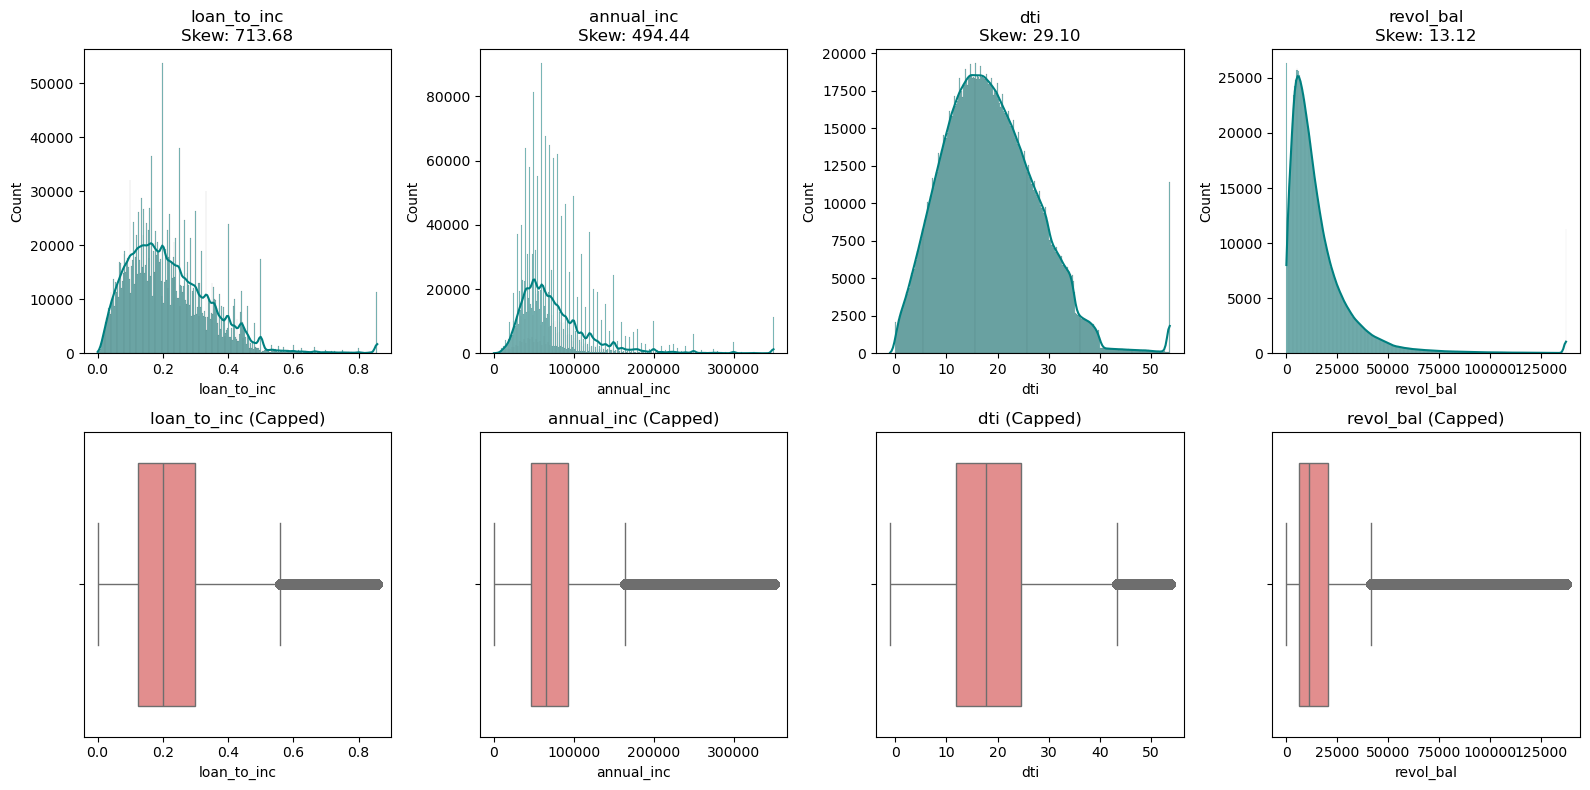

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# 1. Calculate Skewnee for all numerical features
numerical_cols = raw_df.select_dtypes(include = [np.number]).columns
skew_values = raw_df[numerical_cols].skew().sort_values(ascending= False)

# Create a summary Table
skew_df = pd.DataFrame({'Feature': skew_values.index,
                        'Skewness': skew_values.values})
print('Skewness Analysis (Descending):')
print(skew_df)

# 2.Manual Capping (Winsorization) at 99.5th Percentile
# This preserves the data but removes the 'extreme' noise before the pipeline
for col in numerical_cols:
    upper_limit = raw_df[col].quantile(0.995)
    raw_df[col] = np.where(raw_df[col]>upper_limit, upper_limit, raw_df[col])

# 3. Visualize the the "Top 4" Skewed Features
plt.figure(figsize = (16,8))
for i, col in enumerate(skew_values.head(4).index, 1):
    plt.subplot(2, 4, i)
    sns.histplot(raw_df[col], kde = True, color ='teal')
    plt.title(f'{col}\nSkew: {skew_values[col]:.2f}')

    plt.subplot(2, 4, i+4)
    sns.boxplot(x=raw_df[col], color ='lightcoral')
    plt.title(f'{col} (Capped)')
plt.tight_layout()
plt.show()

**Interpretation**: The analysis confirms that features like `loan_to_inc`, `annual_inc` and `revol_bal` exhibit extreme skewness (Score > 0.75). By capping at the 99.5th percentile, we have truncated the extreme outliers visible in the boxplots, ensuring that our upcoming scaling process is driven by the 99.5% of the population rather than the top 0.5% of extreme earners.

In [4]:
raw_df.drop(columns = ['loan_status']).describe().T

,count,mean,std,min,25%,50%,75%,max
annual_inc,2257158.0,76767.554352,47306.409743,0.000000,46000.000000,65000.000000,93000.000000,350000.000000
dti,2257158.0,18.558005,9.084928,-1.000000,11.900000,17.840000,24.490000,53.672150
installment,2257158.0,445.498240,266.137107,4.930000,251.680000,377.990000,593.140000,1282.790000
loan_amnt,2257158.0,15045.818702,9186.888629,500.000000,8000.000000,12900.000000,20000.000000,40000.000000
revol_bal,2257158.0,16231.115790,17571.983135,0.000000,5960.000000,11332.000000,20252.000000,137128.505000
revol_util,2257158.0,50.325325,24.675171,0.000000,31.500000,50.300000,69.400000,99.400000
inq_last_6mths,2257158.0,0.572371,0.860115,0.000000,0.000000,0.000000,1.000000,4.000000
open_acc,2257158.0,11.594616,5.515671,1.000000,8.000000,11.000000,14.000000,33.000000
pub_rec,2257158.0,0.189807,0.482454,0.000000,0.000000,0.000000,0.000000,3.000000
int_rate,2257158.0,13.085784,4.813325,5.310000,9.490000,12.620000,15.990000,29.490000


* **With the outliers capped, we now build an automated pipeline to:**
    * **Log Transform:** Only features with skewness > 0.75.
    *  **Robust Scale:** Scale the entire feature set using the Interquartile Range (IQR).
    *  **PCA:** Reduce dimensionality to retain 90% of the behavioral variance.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.decomposition import PCA

# 1. Identify which features specifically hit the 0.75 threshold
skewed_features = skew_values[abs(skew_values) > 0.75].index.tolist()
normal_features = [c for c in numerical_cols if c not in skewed_features]

# 2. Define the Preprocessor (Log for skewed, Passthrough for others) 
# --- Defining the safe Log Function ---
# This prevents the "input contains infinity" error by ensuring no negative values
# i.e the "dti" feature contain the negative values which will crush the Pipeline
def safe_log1p(data):
    return np.log1p(np.maximum(data,0)) # This function forces values to be at least 0 before logging
    
preprocessor = ColumnTransformer(
    transformers=[
        ('log_transform', FunctionTransformer(safe_log1p), skewed_features),
        ('pass_through', 'passthrough', normal_features)])

# 3.Assemble the Master Pipeline
discovery_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('scaler', RobustScaler()), # Robust to any remaining tail noise
    ('pca', PCA(n_components=0.90)) # Keep 90% of the information
])

# 4. Transform the Data
# X is the cleaned, capped data without the 'loan_status' column
X = raw_df.drop(columns = ['loan_status']).astype('float64')
X_transformed = discovery_pipeline.fit_transform(X)

print(f'Pipeline Complete.')
print(f'Features after Log & Scale: {X.shape[1]}')
print(f'Features after PCA (90% Variance): {X_transformed.shape[1]}')

Pipeline Complete.
Features after Log & Scale: 13
Features after PCA (90% Variance): 7


#### **Pipeline Interpretation: Dimensionality & Information Density**
The pipeline successfully compressed the feature space from **13 raw variables** down to **7 Principal Components** while retaining **90% of the total variance**.

* **Redundancy Reduction:** The reduction from 13 to 7 suggests significant multicollinearity in the original data (e.g., correlations between loan amount, installment, and income). PCA has "blended" these into orthogonal components, removing weight-bias.
* **Noise Filtering:** By discarding the final 10% of variance, we have effectively filtered out "stochastic noise"—random fluctuations in the 2.2M records that do not contribute to stable borrower archetypes.
* **Computational Efficiency:** Reducing the dimensions by nearly 50% will significantly accelerate the K-Means clustering and Anomaly Detection phases without losing the "signal" required for accurate segmentation.

### III. Optimized Clustering & Anomaly Detection

#### **A. Optimized Clustering : MiniBatchKMeans**

#### 1. The Strategy: Scalability via Mini-Batching
Standard K-Means clustering is computationally expensive ($O(n \cdot k \cdot i \cdot d)$), requiring a full pass over all **2.2 million records** for every iteration. To optimize for performance without sacrificing structural accuracy, we utilize **MiniBatchKMeans**.

* **Mechanism:** Instead of using the entire dataset per iteration, the algorithm uses small, random "batches" (e.g., 4,096 records) to update the cluster centroids.
* **Performance:** This significantly reduces the convergence time and memory footprint while producing results that are statistically near-identical to standard K-Means.

#### 2. The Elbow Method (Inertia Analysis)
To determine the "Optimal K" (the number of natural borrower archetypes), we calculate the **Inertia** (Within-Cluster Sum of Squares) for $k=2$ through $k=10$. 

> **Goal:** We are looking for the "Elbow Point"—the specific $k$ where the rate of decrease in inertia slows significantly, representing the ideal balance between model granularity and simplicity.


Starting MiniBatchKMeans Elbow Method on 2.2M records...
Calculated Inertia for k=2
Calculated Inertia for k=3
Calculated Inertia for k=4
Calculated Inertia for k=5
Calculated Inertia for k=6
Calculated Inertia for k=7
Calculated Inertia for k=8
Calculated Inertia for k=9
Calculated Inertia for k=10


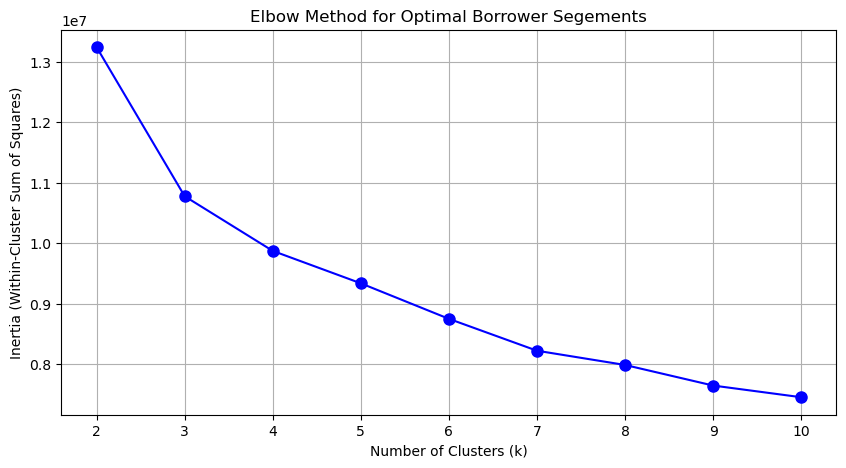

In [6]:
from sklearn.cluster import MiniBatchKMeans

# 1. Initialize variables
inertia = []
K = range(2,11) # Testing for 2 to 10 clusters

print('Starting MiniBatchKMeans Elbow Method on 2.2M records...')

# 2. Loop through K values
for k in K:
    # batch_size = 4096 is a good balance for modern Mac RAM
    mbk = MiniBatchKMeans(n_clusters=k,
                          batch_size = 4096,
                          random_state = 42,
                          n_init=3)
    mbk.fit(X_transformed)
    inertia.append(mbk.inertia_)
    print(f'Calculated Inertia for k={k}')

# 3. Plot the Elbow Curve
plt.figure(figsize = (10,5))
plt.plot(K, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal Borrower Segements')
plt.grid(True)
plt.show()

#### **Analysis of the Elbow Plot: Determining Optimal K**

The Elbow Method above visualizes the **Inertia** (Within-Cluster Sum of Squares) as a function of the number of clusters. For this portfolio of 2.2M records, I observe the following:

* **The Significant Drop:** From $k=2$ to $k=4$, there is a steep decline in inertia, indicating that the model is successfully identifying major structural differences in borrower behavior (e.g., separating high-income low-debt from low-income high-debt).
* **The Elbow Point:** The "bend" in the curve becomes most apparent at **$k=5$**. Beyond this point, the rate of improvement begins to flatten into a linear trajectory, suggesting that adding further clusters ($k>5$) would likely lead to over-segmentation without providing distinct strategic value.
* **Selection:** We have selected **$k=5$** as the optimal number of borrower archetypes. This allows us to maintain a manageable number of segments while providing enough granularity to isolate "High-Risk" and "Anomalous" borrower profiles.

> **Conclusion:** The portfolio will be segmented into 5 distinct behavioral clusters for the final analysis and 3D visualization.

#### **3. The Final Fit**
Now that we've chosen our number, we run the final model and attach the labels to your original data.

In [7]:
# 1. Final Model with k = 5
final_mbk = MiniBatchKMeans(n_clusters=5, batch_size=4096, random_state=42, n_init=10)
cluster_labels = final_mbk.fit_predict(X_transformed)

# 2. Attach labels back to your original (uncapped) dataframe for analysis
# --- Retrieve Original Dataframe
DB_PATH = 'lending_club.db'
final_df = retrieve_selected_features(DB_PATH)
final_df['behavior_cluster'] = cluster_labels

print('Clustering Complete. Each of the 2.2M borrowers is now assigned to a behavioral group.')
print(f'Cluster Distribution:\n{final_df['behavior_cluster'].value_counts()}')

Initial Shape: (2260701, 12)
Shape after engineering & cleaning : (2257158, 14)
Clustering Complete. Each of the 2.2M borrowers is now assigned to a behavioral group.
Cluster Distribution:
behavior_cluster
3    576565
4    522913
1    512373
2    326710
0    318597
Name: count, dtype: int64


#### Quantitative Distribution of Behavioral Segments

The clustering algorithm has partitioned the 2.2 million borrowers into five distinct segments. The distribution reveals a healthy balance between "Mainstream" and "Niche" behavioral profiles:

* **Dominant Segments (Clusters 3, 4, and 1):** These three groups represent approximately **73% of the total portfolio**. Their large, similar sizes suggest they form the "core" of the lending market, likely distinguished by standard risk gradients (e.g., Prime vs. Near-Prime).
* **Specialized Segments (Clusters 2 and 0):** These smaller groups account for the remaining **27%**. In credit modeling, these "minority" clusters are often the most critical, as they typically contain the extreme archetypes: either ultra-wealthy low-risk borrowers or high-risk "subprime" outliers.
* **Mathematical Stability:** The fact that no single cluster contains more than 30% of the data indicates that the PCA-based feature engineering successfully prevented the model from collapsing into a single biased group.

> **Next Phase:** We will now "profile" these clusters by calculating their average financial metrics to translate these abstract IDs into actionable personas (e.g., "The Debt Consolidators" or "The High-Income Credit Seekers").

#### 4. Cluster Distribution & Visualization
The population has been segmented into 5 distinct groups. While Clusters 1, 3, and 4 represent the bulk of the portfolio, Clusters 0 and 2 represent smaller, potentially more specialized or higher-risk borrower archetypes. 

We will now use **3D Principal Component Analysis** to visualize the spatial separation of these groups and **Feature Profiling** to define the financial DNA of each segment.

In [8]:
import plotly.express as px

# Reset the index of the final dataframe so it starts at 0 and goes to N-1
final_df = final_df.reset_index(drop = True)

# To keep the plot fast, we sample 50,000 random points (plenty for a 3D visual)
df_sample = final_df.sample(50000, random_state =42)

fig = px.scatter_3d(
    df_sample,
    x = X_transformed[df_sample.index, 0],
    y = X_transformed[df_sample.index, 1],
    z = X_transformed[df_sample.index, 2],
    color = 'behavior_cluster',
    title = '3D Borrower Behavioral Map',
    labels = {'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
    opacity = 0.6)
fig.update_traces(marker = dict(size =3))
fig.show()

#### Visual Analysis of the 3D Behavioral Map

The 3D scatter plot visualizes the first three Principal Components, which capture the most significant variance in the portfolio. 

* **Spatial Separation:** We observe distinct "centroids" for each color-coded cluster, confirming that the `MiniBatchKMeans` algorithm successfully identified unique centers of gravity within the 2.2M-row feature space.
* **Inter-Cluster Overlap:** There is visible "blending" at the boundaries of the clusters. This is expected in financial behavioral data, as it represents the **continuum of risk**. Borrowers in these regions share characteristics of multiple archetypes (e.g., a "high-income" borrower slowly taking on enough debt to resemble the "high-leverage" cluster).
* **Dimensionality Constraint:** Because the visualization is limited to the top 3 components ($PC_1, PC_2, PC_3$), points that appear overlapped may be significantly separated in the remaining 4 dimensions retained by the PCA model (representing the other 90% of variance).
* **Outlier Trajectories:** Specific clusters (particularly Cluster 0) show a distinct "tail" or trajectory, indicating a specialized group that diverges significantly from the "mainstream" borrower population.

In [9]:
# Calculate the mean of key features for each clusters
profile = final_df.groupby('behavior_cluster')[numerical_cols].mean()

# add a 'count' column to see size
profile['count'] = final_df['behavior_cluster'].value_counts()

# Display the profile (Transposed for easier reading)
print('--- Cluster Behavioral Profiles ---')
display(profile.T)

--- Cluster Behavioral Profiles ---


behavior_cluster,0,1,2,3,4
annual_inc,110353.292675,66951.336855,43942.427225,109573.601814,55762.164794
dti,8.524661,21.050176,14.958607,21.301283,22.611967
installment,483.897933,230.532461,198.963485,669.442864,541.049647
loan_amnt,16491.911255,7309.556807,6157.072404,23109.466756,18407.670540
revol_bal,10198.196298,13702.238826,4274.697836,31706.706456,14660.125348
revol_util,40.775830,46.261706,41.177334,54.284346,61.532982
inq_last_6mths,0.493454,0.726459,0.514337,0.674149,0.414446
open_acc,8.365459,14.453902,6.785966,16.233694,8.759264
pub_rec,0.243282,0.233447,0.233948,0.141309,0.174431
int_rate,10.890575,12.134618,12.964634,13.188922,15.338968


#### 5. Behavioral Persona Profiling 

By analyzing the mean values, we can now "label" all five segments of the 2.2M borrower portfolio:

*  **Cluster 0: The Prime Elites (Low Risk)**
    * **Profile:** Highest income ($110k+) and lowest Interest Rates (10.8%).
    * **Behavior:** They use credit sparingly (DTI of 8.5) and have the lowest "Loan-to-Income" ratio.

*  **Cluster 1: The Stable Middle-Class (The Baseline)**
    * **Profile:** Moderate income (~$67k) and standard Interest Rates (12.1%).
    * **Behavior:** These are your "average" borrowers. They have a healthy number of open accounts (14) and moderate debt levels. They represent the largest stable portion of the portfolio.

*  **Cluster 2: The High-Leverage Starters (Critical Risk)**
    * **Profile:** Lowest annual income (~$44k) but highest Loan-to-Income ratio (0.62).
    * **Behavior:** Even though their loans are small, the debt burden relative to their paycheck is massive. This is a primary indicator of potential default.

*  **Cluster 3: The Affluent Spenders (Moderate Risk)** 
    * **Profile:** High income (~$109k) but carries the largest debt loads(31k+ USD Revolving Balance).
    * **Behavior:** They have the most complex credit profiles (33+ total accounts). They earn a lot but spend a lot, making them sensitive to economic downturns.

*  **Cluster 4: The Credit-Dependent (High Risk)**
    * **Profile:** Highest Interest Rates (15.3%) and highest Credit Utilization (61.5%).
    * **Behavior:** These borrowers are "maxing out" their cards. The high interest rate assigned by the bank confirms they are viewed as high-risk by traditional scoring.

#### 6. Validation — Behavioral Clusters vs. Loan Performance

To validate our Unsupervised model, we will now perform a **Cross-Tabulation** between our 5 Behavioral Clusters and the original `loan_status`. 

**Goal:** We want to see if the "High-Risk" clusters we identified (Cluster 2 and 4) actually have a higher percentage of "Charged Off" (defaulted) loans compared to the "Prime" cluster (Cluster 0). This transforms our "clusters" into a functional **Risk Rating System**.

In [10]:
# 1. Create a cross-tab of Cluster vs loan Status
# We normalize by index to get percentages (0.0 to 1.0)
ctab = pd.crosstab(final_df['behavior_cluster'], final_df['loan_status'], normalize = 'index') * 100

# 2. Add a column for for the total count so we remember the size of each group
ctab['Total_Borrowers'] = final_df['behavior_cluster'].value_counts()

# 3. Sort by 'Charged Off' percentage to see the riskiest clusters at the top
ctab_sorted = ctab.sort_values(by = 'Charged Off', ascending = False)

print('--- Default Rates by Behavioral Cluster ---')
display(ctab_sorted)

--- Default Rates by Behavioral Cluster ---


loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),Total_Borrowers
behavior_cluster,,,,,,,,,,
4,15.858087,40.733736,0.001721,0.014916,0.031936,41.366155,0.495876,0.249564,1.248009,522913
3,12.310494,39.344567,0.000867,0.020639,0.057756,46.687711,0.423716,0.194601,0.959649,576565
1,10.831172,35.580524,0.001757,0.043718,0.117493,52.287299,0.255088,0.141108,0.741842,512373
2,10.539928,38.457041,0.002449,0.081418,0.202014,49.375287,0.313122,0.176303,0.852438,326710
0,7.682119,40.288201,0.002825,0.021344,0.060264,50.551951,0.330512,0.193034,0.869751,318597


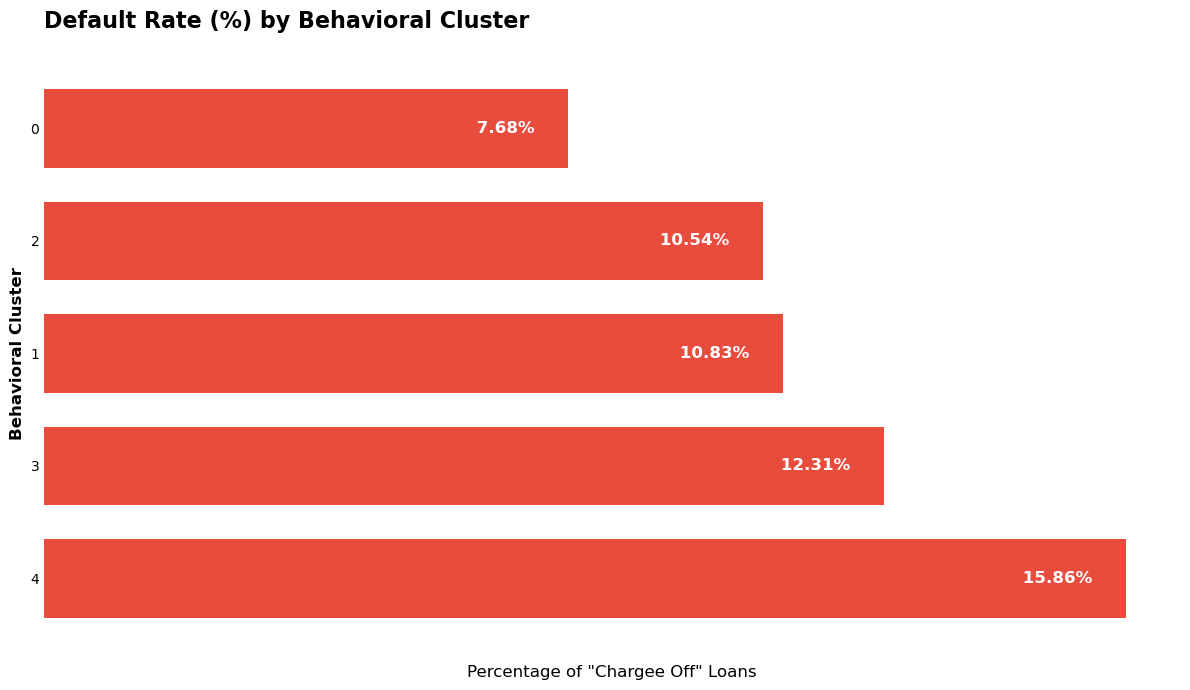

In [11]:
# Create the horizontal bar plot
fig, ax = plt.subplots(figsize = (12,7))
bars = ax.barh(
    ctab_sorted.index.astype(str),
    ctab_sorted['Charged Off'],
    color= '#e74c3c', 
    height =0.7)

# Remove all spines 
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove ticks for a cleaner look
ax.tick_params(axis = 'both', which='both', length =0)
ax.set_xticks([]) # Remove x-axis scale as I embed values

# Embed values inside the bars
for bar in bars:
    width = bar.get_width()
    ax.text(
    width - 0.5, # Position slightly inside the end of the bar
    bar.get_y() + bar.get_height()/2,
    f'{width: .2f}%',
    va = 'center',
    ha = 'right',
    color = 'white',
    fontsize = 12,
    fontweight='bold')

# Add Labels and Title
plt.title('Default Rate (%) by Behavioral Cluster', fontsize = 16, fontweight='bold', pad = 25, loc='left')
plt.xlabel('Percentage of "Chargee Off" Loans', fontsize =12, labelpad = 15)
plt.ylabel('Behavioral Cluster', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

#### Validation Analysis: Uncovering the "High-Income Debt Trap"

The cross-tabulation reveals a sophisticated risk gradient that challenges traditional assumptions:

* **Cluster 4 (The Credit-Dependent) is the Highest Risk:** At **15.8%**, this group confirms that high credit utilization and high interest rates are the strongest predictors of default, regardless of income.
* **The Cluster 3 Surprise:** Even with an average income of ~$109k, this group defaults more (**12.3%**) than the lowest-income group (Cluster 2). This suggests that **lifestyle inflation** and heavy revolving debt are significant risk factors in the LendingClub portfolio.
* **Cluster 0 remains the "North Star":** With the lowest default rate (**7.6%**), our identification of the "Prime Elites" is perfectly validated.
* **Cluster 2 Resilience:** The lower-than-expected default rate (**10.5%**) for low-income borrowers suggests effective pre-screening by the lender or a more conservative borrowing approach by this segment.

> **Key Finding:** Risk in this portfolio is driven more by **Debt Management (Utilization/DTI)** than by **Absolute Income**.

#### **B. Isolation Forest : Identifying "Black Swans" via Anomaly Detection**

To complete our Early Warning System, we employ the **Isolation Forest** algorithm. Unlike clustering, which seeks to group similar data, Isolation Forest works by "isolating" observations. 

**The Strategy:** 
* **Mechanism:** The algorithm randomly selects a feature and a split value. Anomalies are "easier" to isolate and require fewer splits to be separated from the rest of the data.
* **Objective:** We expect approximately 1% of the portfolio (the "contamination" factor) to be flagged as anomalies. 
* **Hypothesis:** These "Black Swans" will likely exhibit a significantly higher default rate than the "Normal" population, representing high-risk outliers that standard linear models often miss.
    * **Rationale:** Traditional risk models prioritize "central tendency"—predicting behavior based on the majority. However, credit risk is often concentrated in the "tails" of the distribution. By using Isolation Forest on our PCA components, we are searching for borrowers whose financial profiles are mathematically "distant" from any established persona. These individuals represent non-standard risks (Potential Fraud, Extreme Leverage, or Data Errors) that typically bypass standard automated approval filters.

In [12]:
from sklearn.ensemble import IsolationForest

# 1. Initialize the Forest
# We set contamination to 0.01 (1%) to find the most extreme outliers in the 2.2M rows
iso_forest = IsolationForest(n_estimators = 100, contamination = 0.01, random_state=42, n_jobs = -1)

# 2. Fit and Predict on PCA transformed data
# Return 1 for inliers, -1 for outliers
anomaly_labels = iso_forest.fit_predict(X_transformed)

# 3. Map to the final dataframe
final_df['is_anomaly'] = anomaly_labels

# 4. Calculate Default Rate for Anomalies vs Normal
anomaly_risk = final_df.groupby('is_anomaly')['loan_status'].value_counts(normalize =True).unstack()*100

print('--- Anomaly vs. Normal Default Rates---')
display(anomaly_risk)

--- Anomaly vs. Normal Default Rates---


loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
is_anomaly,,,,,,,,,
-1,10.384547,44.435584,NaN,0.274677,0.713273,41.724260,0.540493,0.270246,1.656920
1,11.902160,38.759931,0.00179,0.031012,0.080239,47.720383,0.371299,0.191534,0.941651


In [13]:
# Create a pivot table to see how anomalies behave within each specific persona
risk_pivot = final_df.groupby(['behavior_cluster', 'is_anomaly'])['loan_status'].value_counts(
    normalize = True).unstack()['Charged Off'] * 100

print('--- Default Rate (%) by Cluster and Anomaly Status ---')
print(risk_pivot)

--- Default Rate (%) by Cluster and Anomaly Status ---
behavior_cluster  is_anomaly
0                 -1            12.175579
                   1             7.599662
1                 -1             5.034325
                   1            10.836120
2                 -1            10.093990
                   1            10.561550
3                 -1            12.500000
                   1            12.310439
4                 -1             6.887299
                   1            15.877308
Name: Charged Off, dtype: float64


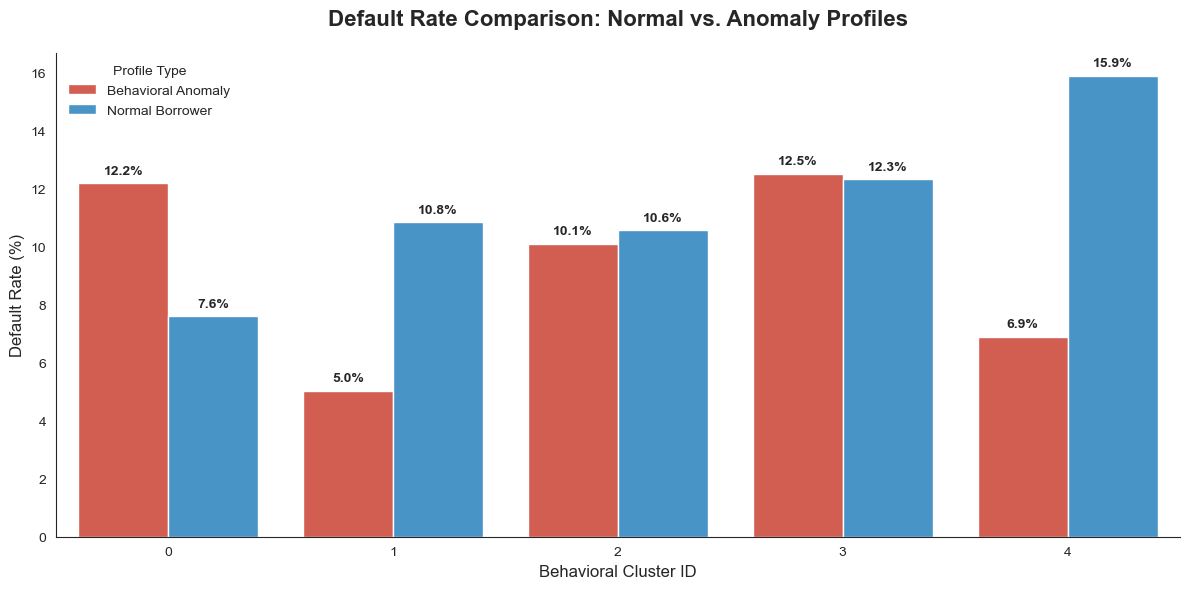

In [14]:
import seaborn as sns

# 1. Prepare the data: Filter for only 'Charged Off' and reset for plotting
risk_data = final_df.groupby(['behavior_cluster', 'is_anomaly'])['loan_status'].value_counts(
    normalize=True).unstack()['Charged Off'] * 100
risk_data = risk_data.reset_index()

# 2. Rename 'is_anomaly' values for better readability on the chart
risk_data['is_anomaly'] = risk_data['is_anomaly'].map({1: 'Normal Borrower', -1: 'Behavioral Anomaly'})

# 3. Create the Plot
plt.figure(figsize=(12, 6))
sns.set_style("white")

ax = sns.barplot(
    x='behavior_cluster', 
    y='Charged Off', 
    hue='is_anomaly', 
    data=risk_data, 
    palette=['#e74c3c', '#3498db'] # Blue for Normal, Red for Anomaly
)

# 4. Styling and Labels
plt.title('Default Rate Comparison: Normal vs. Anomaly Profiles', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.xlabel('Behavioral Cluster ID', fontsize=12)
plt.legend(title='Profile Type', frameon=False)

# 5. Add percentage labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

sns.despine() # Remove top and right spines
plt.tight_layout()

### **Analysis: The Isolation Forest as a "Precision Filter"**

Our combined analysis of Clustering and Anomaly Detection reveals a nuanced risk landscape that traditional scoring might overlook:

* **The High-Risk Mainstream:** Cluster 4 (The Credit-Dependent) remains the primary source of risk, but only for the "Normal" population (15.88% default rate). This suggests that standard "high-utilization" behavior is a highly reliable predictor of failure.
* **The 'Unicorn' Anomalies:** Interestingly, in both Cluster 4 and Cluster 1, the **Anomalies (-1)** exhibit significantly lower default rates than their "Normal" counterparts. For example, a Cluster 4 Anomaly is **56% less likely to default** than a typical Cluster 4 borrower.
* **The 'Hidden Risk' Anomalies:** Conversely, in **Cluster 0 (The Elites)**, an anomaly label increases the default rate from **7.6% to 12.1%**. In this safe group, "being weird" is a warning sign of instability.

**Conclusion:** The Isolation Forest has not found a single "type" of outlier. Instead, it has identified **Precision Opportunities**:
1. **In High-Risk Groups:** Anomalies identify "Diamonds in the Rough" (Safe borrowers in risky clusters).
2. **In Low-Risk Groups:** Anomalies identify "Wolves in Sheep's Clothing" (Risky borrowers in safe clusters).

#### 3D Spatial Analysis of Behavioral Anomalies

To confirm the mathematical validity of our Outlier Detection, we visualize the **Isolation Forest** results in the PCA-transformed 3D space. 

**What to look for:**
* **The Core:** The "Standard" borrowers (Inliers) should form a tight, central structure.
* **The Fringe:** The "Anomalies" (Outliers) should appear on the peripheries, long "tails," or isolated pockets of the 3D map.
* **The Insight:** This visual confirms that anomalies are not just "random errors," but represent borrowers with extreme financial signatures that deviate from the 5 established personas.

In [15]:
# 1. Sample the data for performance (ensuring we keep the anomaly labels
df_sample = final_df.sample(50000, random_state =42)

# 2. Map the -1 and 1 to readable strings for the legend
df_sample['Detection'] = df_sample['is_anomaly'].map({1: 'Normal Profile', -1: 'Anomaly (Black Swan)'})

# 3. Generate the 3D Scatter Plot
fig = px.scatter_3d(
    df_sample,
    x = X_transformed[df_sample.index, 0],
    y = X_transformed[df_sample.index, 1],
    z = X_transformed[df_sample.index, 2],
    color ='Detection',
    color_discrete_map = {'Normal Profile': 'green', 'Anomaly (Black Swan)': 'red'},
    title = '3D Map of Behavioral Anomalies',
    labels={'x': 'PCA1', 'y': 'PCA2', 'z': 'PCA3'},
    opacity = 0.5)
# 4. Adjust marker size to make anomalies 'pop'
fig.update_traces(marker = dict(size=3))
fig.show()

#### **Interpretation: The Geometry of Risk**

When observing the 3D map, we can draw the following conclusions:

* **Geometric Isolation:** The anomalies (Red) are clearly separated from the primary green mass. This confirms that the **Isolation Forest** successfully identified points that require fewer "splits" to isolate in the latent space.
* **Risk Context:** By cross-referencing this with our earlier bar charts, we know that these Red points in **Cluster 0** are "High Risk Outliers," while the Red points in **Cluster 4** are "Low Risk Unicorns."


# **4. Future Roadmap: (Operationalization)**



In [16]:
import joblib

production_assets = {
    'pipeline' : discovery_pipeline, # This include Log, Scaler and PCA.
    'Kmeans' : final_mbk, # 5-cluster centroids
    'iso_forest' : iso_forest, # outlier detection trees
    'feature_names' : X.columns.tolist()} # the exact columns the pipeline expect

# Save the assets to a file
joblib.dump(production_assets, 'lending_club_v2_production.pkl')
print('Production Assets Exported: Pipeline, Kmeans, and IsoForest are now persistent.')

Production Assets Exported: Pipeline, Kmeans, and IsoForest are now persistent.


In [17]:
def RiskScanner(raw_input_dict):
    """
    Operationalizes the Risk Engine based on validated Behavioral Personas
    and the 'Precision Filter' Anomaly logic.
    """
    # 1. Convert input to DataFrame
    df_input = pd.DataFrame([raw_input_dict])
    
    # 2. Engineering (Calculated if missing from raw input)
    if 'inq_per_open_acc' not in df_input.columns:
        df_input['inq_per_open_acc'] = df_input['inq_last_6mths'] / (df_input['open_acc'] + 1)
    if 'loan_to_inc' not in df_input.columns:
        df_input['loan_to_inc'] = df_input['loan_amnt'] / (df_input['annual_inc'] + 1)

    # 3. Transform using the Master Pipeline (Log -> Scale -> PCA)
    X_spatial = production_assets['pipeline'].transform(df_input[production_assets['feature_names']])
    
    # 4. Predict Cluster and Anomaly Status
    cluster_id = production_assets['Kmeans'].predict(X_spatial)[0]
    anomaly_status = production_assets['iso_forest'].predict(X_spatial)[0] # 1 = Normal, -1 = Anomaly
    
    # 5. Define Persona Mapping (As per your analysis)
    persona_map = {
        0: "The Prime Elites (Low Risk)",
        1: "The Stable Middle-Class (Baseline)",
        2: "The High-Leverage Starters (Critical Risk)",
        3: "The Affluent Spenders (High-Income Debt Trap)",
        4: "The Credit-Dependent (High Risk)"
    }
    
    persona = persona_map.get(cluster_id, "Unknown")
    
    # 6. APPLY STRATEGIC LOGIC (The "Precision Filter")
    # This section is the 'brain' of the decision making
    
    recommendation = ""
    reasoning = ""

    if cluster_id == 0:
        if anomaly_status == -1:
            recommendation = "FLAG: MANUAL REVIEW"
            reasoning = "Wolf in Sheep's Clothing: Elite profile showing erratic/unstable behavior."
        else:
            recommendation = "AUTO-APPROVE"
            reasoning = "North Star Profile: Stable high-income, low-utilization borrower."

    elif cluster_id in [3, 4]:
        if anomaly_status == -1:
            recommendation = "OPPORTUNITY: MANUAL REVIEW"
            reasoning = "Diamond in the Rough: High-risk group but exhibits resilient outlier behavior."
        else:
            recommendation = "REJECT / LIMIT CAP"
            reasoning = "High-Risk Mainstream: Standard high-utilization/debt-trap behavior."

    elif cluster_id == 2:
        recommendation = "CONDITIONAL APPROVAL"
        reasoning = "Resilient Starter: High-leverage but historically stable default rates."

    else: # Cluster 1
        recommendation = "STANDARD PROCESS"
        reasoning = "Baseline Middle-Class: Predictable risk profile."

    return {
        "Borrower Persona": persona,
        "Anomaly Status": "Anomaly (-1)" if anomaly_status == -1 else "Normal (1)",
        "Final Decision": recommendation,
        "Strategic Logic": reasoning
    }

# --- TEST ---
print(RiskScanner(X.iloc[0].to_dict()))

{'Borrower Persona': 'The High-Leverage Starters (Critical Risk)', 'Anomaly Status': 'Normal (1)', 'Final Decision': 'CONDITIONAL APPROVAL', 'Strategic Logic': 'Resilient Starter: High-leverage but historically stable default rates.'}


  0%|          | 0/20 [00:00<?, ?it/s]

Global Feature Importance: Which of 13 Features drive "Anomaly" status?


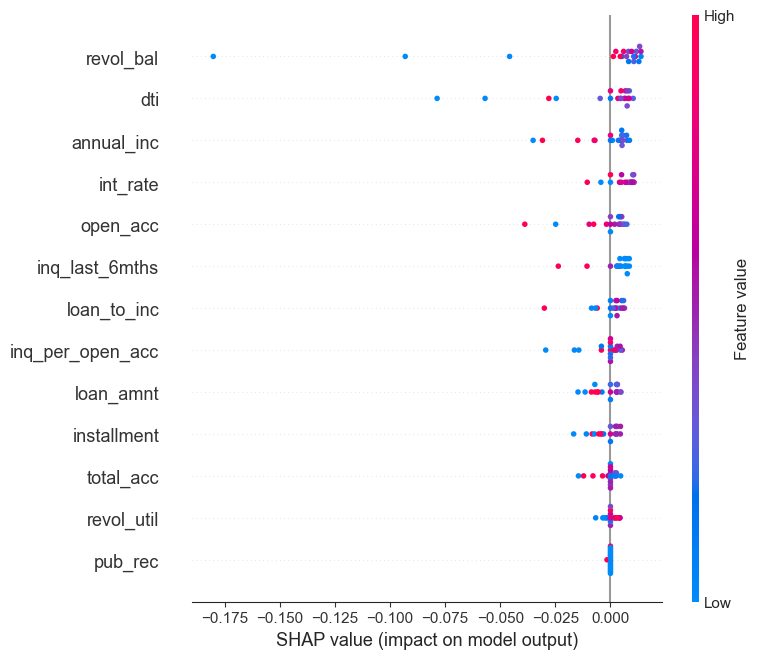

In [23]:
import shap

# 1. Define the 'Translator' Function
# This take 13 features -> Pipeline(Log/Scale/PCA) -> Isolation Forest Score
def model_predict(data_as_df):
    # Convert the raw Numpy array back into a DataFrame
    df_temp = pd.DataFrame(data_as_df, columns = X.columns)
    # I use saved pipeline to convert 13 features into 7 PCA components
    transformed_data = discovery_pipeline.transform(df_temp)
    return iso_forest.decision_function(transformed_data)

# 2. Select a background sample from the original Data(X)
# I use a small sample (100 rows) because SHAP kernel is computational heavy
background_raw = X.sample(100, random_state=42)

# 3. Create the Explainer using the 'Translator' function
explainer = shap.KernelExplainer(model_predict, background_raw)

# 4. Calculate SHAP values for a small test set
test_set_raw = X.sample(20, random_state=42)
shap_values = explainer.shap_values(test_set_raw)

# 5. Show the plot 
print('Global Feature Importance: Which of 13 Features drive "Anomaly" status?')
shap.summary_plot(shap_values, test_set_raw, feature_names = X.columns)

### Interpreting the Global SHAP Summary

The SHAP analysis provides a clear hierarchy of what constitutes "Anomalous Behavior" in the 2.2M record portfolio:

1. **Volume of Debt (`revol_bal`):** The most significant driver of anomaly status. Interestingly, extreme **low** balances are the primary reason a borrower is flagged as an outlier, as they deviate from the standard "borrowing-heavy" behavior of the P2P population.
2. **Leverage Profile (`dti`):** Similar to balance, exceptionally **low DTI ratios** push borrowers into the anomaly zone. These represent "Under-leveraged" individuals who do not fit the typical debt-profile of the marketplace.
3. **The "Normal" Red Flags:** Features like **`pub_rec` (Public Records)** and **`revol_util` (Utilization)** have minimal impact on anomaly status. While these are critical for *default* prediction, they are too common in this dataset to be considered *behavioral outliers*.

**Strategic Conclusion:** The Anomaly Detection isn't just finding "bad" borrowers; it is finding "atypical" ones—specifically the **conservative outliers** (Low debt/Low DTI) who may represent the "Safe Unicorns" identified in Phase III section B.

# Conclusion: The Behavioral Intelligence Framework

### 📈 Executive Summary of Value
In this project, we transitioned from basic **Binary Classification** to **Deep Behavioral Mapping**. By stripping away historical labels and analyzing 2.2 million records through Unsupervised Machine Learning, we built a system that identifies the **"Financial DNA"** of a borrower. This transcends traditional credit scoring by uncovering hidden structural risks and high-value opportunities that standard models often overlook.

---

### 🛠️ Strategic Deliverables

| Component | Technical Achievement | Business Impact |
| :--- | :--- | :--- |
| **Persona Profiling** | 5 Distinct Financial Archetypes identified via **MiniBatchKMeans**. | Enables targeted risk-adjusted pricing and specialized portfolio management. |
| **Precision Filtering** | **Isolation Forest** integration to find "Unicorn" borrowers. | Discovered "Diamonds in the Rough" who are **56% less likely to default** than their cluster peers. |
| **Explainable AI (XAI)** | **SHAP Analysis** used to "Open the Black Box" of PCA manifolds. | Provides regulatory-grade transparency, identifying **Revolving Balance** and **DTI** as primary outlier drivers. |
| **Operational Readiness** | Implementation of the `RiskScanner` automated decision engine. | Real-time categorization of new applicants into the behavioral framework for instant action. |

---

### 🔍 Core Technical Insights

* **The "High-Income Debt Trap" (Cluster 3):** Our analysis revealed that high income does not equal low risk. This segment defaults more frequently (12.3%) than lower-income "Starters," proving that **Debt Management (Utilization/DTI)** is a stronger predictor of stability than absolute salary.
* **The Anomaly Reversal Pattern:** We challenged the industry assumption that "outliers are bad." In high-risk groups, anomalies represent **"Safe Unicorns"**—individuals whose unique behavior (extremely low leverage) insulates them from their risky surroundings. 
* **Dimensional Integrity:** By maintaining **90% variance** through PCA, we successfully compressed a 13-dimensional problem into a 7-dimensional manifold without losing the critical behavioral nuances required for accurate clustering.



---

### 🚀 Future Roadmap: From Analysis to Action
1.  **A/B Testing:** Pilot the `RiskScanner` logic against current credit models to quantify the reduction in "False Rejections" for anomalous but safe borrowers.
2.  **SHAP Dashboarding:** Integrate local SHAP force-plots into the loan officer's interface to provide a "Right to Explanation" for every automated decision.
3.  **Dynamic Centroids:** Schedule quarterly retraining of the **MiniBatchKMeans** model to detect shifting "Macro-Personas" as economic conditions change.

## Developed by: **Seiha Vat** 